In [60]:
# Import all necessary Libraties 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


In [61]:
# Loading the dataset
data = pd.read_csv("C:\\Users\\ASUS\\OneDrive\\Desktop\\DataScience\\Projects\\project_02\\WA_Fn-UseC_-HR-Employee-Attrition.csv")

# displaying data information
data.info()

# displaying the top 10 rows of the data 
data.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [62]:
# Checking for missing values 
missing_counts = data.isnull().sum()
print("Missing Value Counts:")
print(missing_counts)

Missing Value Counts:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole

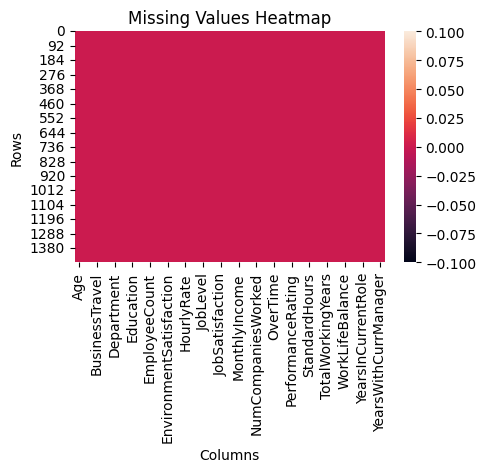

In [63]:
# Showing the data in a heatmap to check for missing values
plt.figure(figsize=(5,3))
sns.heatmap(data.isnull())
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

## After checking all 35 columns and heatmap, this dataset has zero missing values.
This is expected — the IBM HR dataset is synthetically generated and pre-cleaned.

However, I still need to check for:
- Duplicate rows
- Useless columns that add no analysis value
- Columns with only one unique value (these tell us nothing)

In [64]:
data_work = data.copy()

# checking the shape of the data_work
print("Shape of the data_work:", data_work.shape)


Shape of the data_work: (1470, 35)


In [65]:
# Checking for duplicate values 
duplicate_counts = data_work.duplicated().sum()
print("Duplicate Value Counts:", duplicate_counts)


Duplicate Value Counts: 0


In [66]:
# SHowing the name of the columns that have only one unique value
unique_counts = data_work.nunique()
print("Unique Value Counts:")
print(unique_counts)

Unique Value Counts:
Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear 

In [67]:
# Columns name that have only one unique value and need to be dropped
print("Columns with only one unique value:")
columns_to_drop = unique_counts[unique_counts == 1].index
print(columns_to_drop)


Columns with only one unique value:
Index(['EmployeeCount', 'Over18', 'StandardHours'], dtype='str')


In [68]:
# Drop those columns with only one unique value
print("Columns count before dropping:", len(data.columns))

columns_to_drop = unique_counts[unique_counts == 1].index
data_work = data_work.drop(columns=columns_to_drop)
print("Columns count after dropping:", len(data_work.columns))

# dropped columns name are :
print("Dropped Columns:", columns_to_drop.tolist())


Columns count before dropping: 35
Columns count after dropping: 32
Dropped Columns: ['EmployeeCount', 'Over18', 'StandardHours']


## Why these columns are dropped ?
These columns are dropped because they have only one unique value, which means they do not provide any useful information for analysis or modeling. They do not contribute to the variability in the data and can be considered redundant. Keeping such columns can lead to overfitting in machine learning models and can also make the analysis more complex without adding any value. Therefore, it is a common practice to drop columns with only one unique value to improve the efficiency and performance of data analysis and modeling.




## exploration.

In [69]:
# check shape of the data_work after dropping the columns
print("Shape of the data_work after dropping columns:", data_work.shape)

Shape of the data_work after dropping columns: (1470, 32)


In [70]:
# Check data types of the columns in the data_work
print("Data Type of the columns in data-work:")
data_types = data_work.dtypes
print(data_types)

Data Type of the columns in data-work:
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int64
WorkLifeBalance             int64
YearsAtCo

In [71]:
# Description of the data_work
print("Description of the data_work:")
data_description = data_work.describe()
print(data_description)

Description of the data_work:
               Age    DailyRate  DistanceFromHome    Education  \
count  1470.000000  1470.000000       1470.000000  1470.000000   
mean     36.923810   802.485714          9.192517     2.912925   
std       9.135373   403.509100          8.106864     1.024165   
min      18.000000   102.000000          1.000000     1.000000   
25%      30.000000   465.000000          2.000000     2.000000   
50%      36.000000   802.000000          7.000000     3.000000   
75%      43.000000  1157.000000         14.000000     4.000000   
max      60.000000  1499.000000         29.000000     5.000000   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335                 1.093082    20.329428        0.711561   
min          1.000000                 1.000000    30.000000

In [72]:
# Check Attrition split 
attrition_counts = data_work["Attrition"].value_counts()
print("Attrition Value Counts:")
print(attrition_counts)


Attrition Value Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [73]:
# Check all unique departments in the data_work
unique_departments = data_work["Department"].unique()
print("Unique Departments in the data_work:")
print(unique_departments)

Unique Departments in the data_work:
<StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str


## Visulation part starts from here :

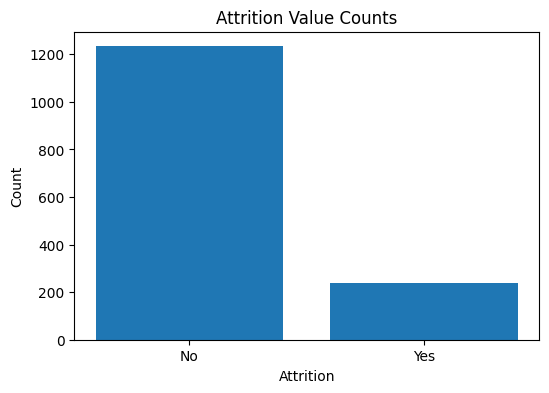

In [74]:
# Visualization of the Attrition split
plt.figure(figsize=(6,4))
plt.bar(attrition_counts.index, attrition_counts.values)
plt.title("Attrition Value Counts")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()


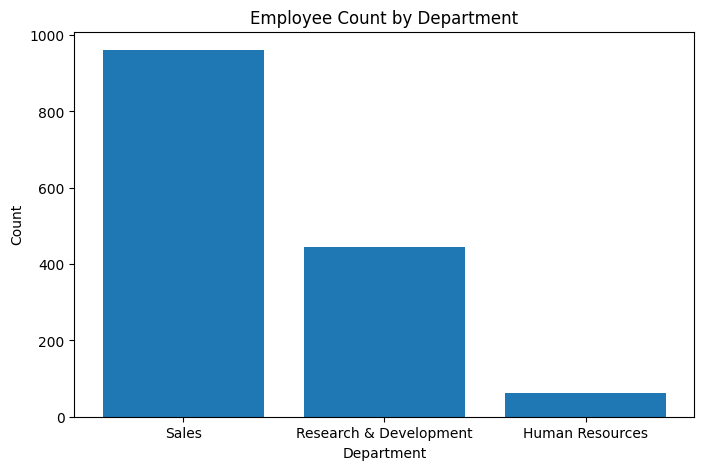

In [75]:
# Visualization of the Employee Count by Department

plt.figure(figsize=(8,5))
plt.bar(unique_departments, data_work["Department"].value_counts().values)
plt.title("Employee Count by Department")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

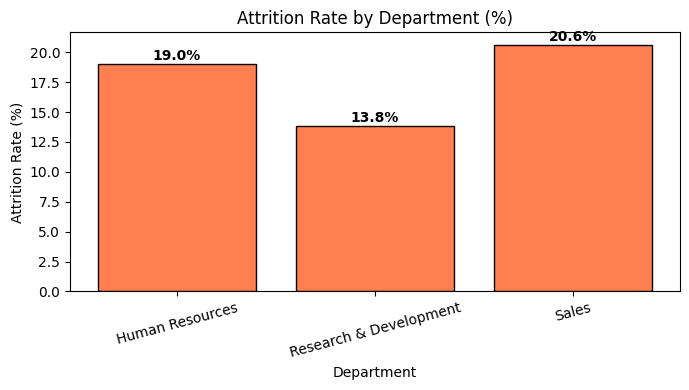

In [76]:
# Chart 3 FIXED — Attrition RATE by department (not raw count)
dept_attrition_rate = data_work.groupby("Department")["Attrition"].value_counts(normalize=True).unstack(fill_value=0) * 100

plt.figure(figsize=(7,4))
bars = plt.bar(dept_attrition_rate.index, dept_attrition_rate['Yes'].values, color='coral', edgecolor='black')
plt.title("Attrition Rate by Department (%)")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=15)

# Add % label on top of each bar
for bar, val in zip(bars, dept_attrition_rate['Yes'].values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f"{round(val,1)}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# explanation of the chart 3 :
# This chart shows the attrition rate (percentage of employees who left) for each department.
# The Sales department has the highest attrition rate at 20.6%, followed by Research
# & Development at 13.8%, and Human Resources at 19.0%. This indicates that employees in the Sales department are more likely to leave compared to the other departments, which 
# may suggest issues related to job satisfaction, work environment, or management in that department. The Research & Development and Human Resources departments also have 
# notable attrition rates, which could warrant further investigation into the factors contributing to employee turnover in those areas.


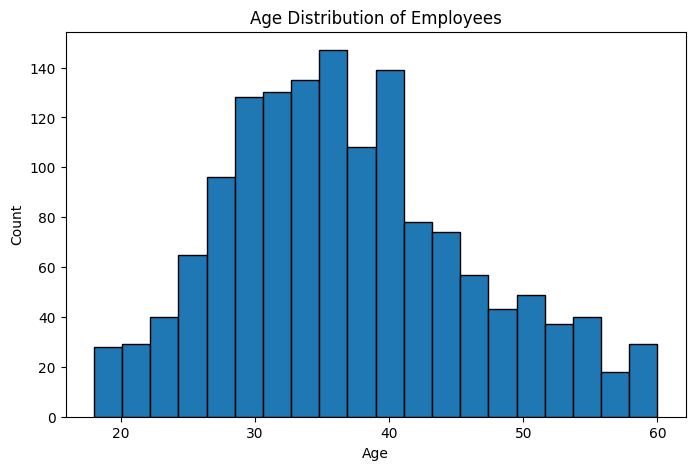

In [77]:
# Visualization age distribution of employees 
plt.figure(figsize=(8,5))
plt.hist(data_work["Age"], bins=20, edgecolor='black')
plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Why histogram is used and bins, edgecolor in the above code:
# A histogram is used to visualize the distribution of a continuous variable, in this case, "Age". It allows us to see how the ages of employees 
# are distributed across different age ranges. The bins parameter specifies the number of intervals (or bins) into which the data is divided.
#  The edgecolor parameter sets the color of the edges of the bars in the histogram.

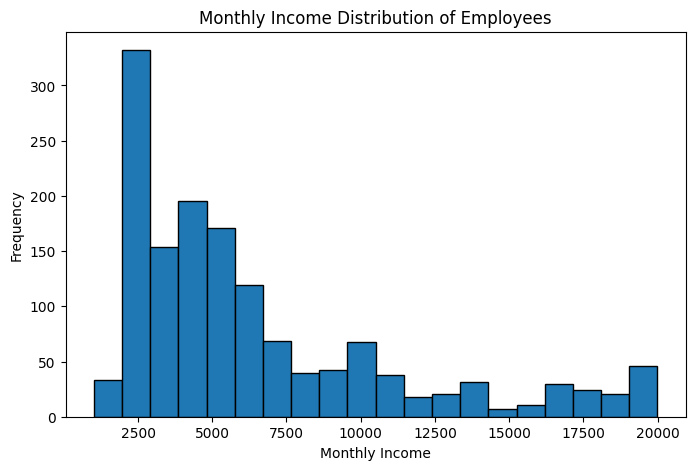

In [78]:
#  Mongthly income distribution of employees
plt.figure(figsize=(8,5))
plt.hist(data_work['MonthlyIncome'], bins= 20 , edgecolor = 'black')
plt.title("Monthly Income Distribution of Employees")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")
plt.show()

## Key Findings

- 16.1% of employees (237 out of 1,470) left the company
- Sales has the highest attrition RATE at 20.6% — not R&D
- R&D looks worst by raw count (133 left) but it's the biggest dept — rate is only 13.8%
- This proves why raw counts are misleading — always use rates for fair comparison
- Workforce age ranges from 18 to 60, average age is 37
- Monthly income ranges widely — from 1,009 to 19,999 USD showing large salary gaps

## What I Learned

- Data cleaning is not just about missing values — useless columns matter too
- Raw count vs percentage rate can tell completely opposite stories
- groupby + unstack is a powerful way to compare categories
- Always ask: "is this count or rate?" before making any bar chart
- Writing comments in code helps me understand my own logic later